# Histopathologic Cancer Detection

**Kaggle Competition**: https://www.kaggle.com/c/histopathologic-cancer-detection

**CU Boulder CSCA-5642 | Mini Project Module 3**

---

This report walks through my approach to detecting metastatic cancer in histopathology images. I'll cover the EDA process, model architecture decisions, and final results.


## Setup


In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

DATA_DIR = 'data/'
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.20.0


## 1. Data Loading

The PatchCamelyon dataset contains 96×96 RGB patches extracted from whole slide images (WSIs). Each patch is labeled as tumor (1) or normal (0).


In [2]:
def load_h5_data(filename, key):
    path = os.path.join(DATA_DIR, filename)
    with h5py.File(path, 'r') as f:
        return f[key][:]

train_x = load_h5_data('camelyonpatch_level_2_split_train_x.h5', 'x')
train_y = load_h5_data('camelyonpatch_level_2_split_train_y.h5', 'y').flatten()
valid_x = load_h5_data('camelyonpatch_level_2_split_valid_x.h5', 'x')
valid_y = load_h5_data('camelyonpatch_level_2_split_valid_y.h5', 'y').flatten()

train_meta = pd.read_csv(os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_train_meta.csv'))

print(f'Training: {train_x.shape[0]:,} images, shape: {train_x.shape[1:]}')
print(f'Validation: {valid_x.shape[0]:,} images')
print(f'Class balance: {train_y.mean():.1%} tumor')


Training: 262,144 images, shape: (96, 96, 3)
Validation: 32,768 images
Class balance: 50.0% tumor


## 2. Exploratory Data Analysis

Before building models, I wanted to understand what I'm working with. The key questions:
- Is the dataset balanced?
- Are there visible differences between tumor and normal tissue?
- Any data quality issues to address?


### 2.1 Class Distribution

Good news - the dataset is perfectly balanced. No need for class weighting or oversampling.


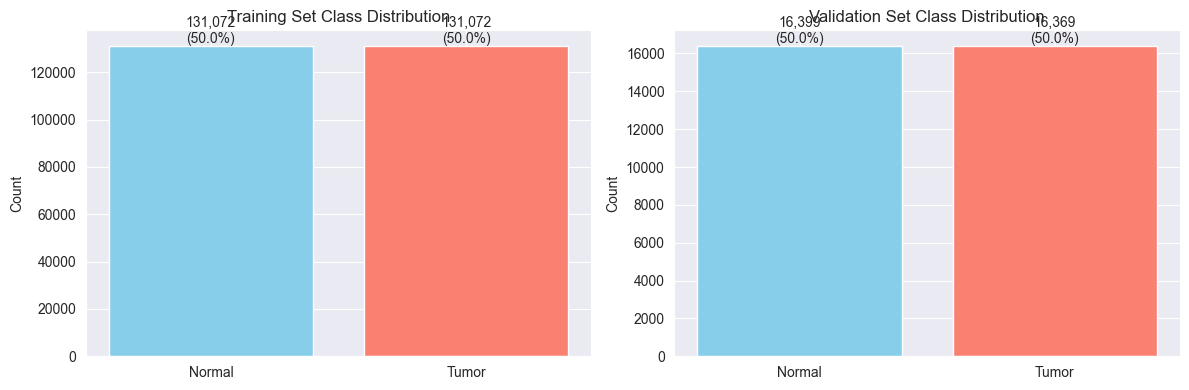

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (data, title) in zip(axes, [(train_y, 'Training'), (valid_y, 'Validation')]):
    counts = [np.sum(data == 0), np.sum(data == 1)]
    ax.bar(['Normal', 'Tumor'], counts, color=['skyblue', 'salmon'])
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax.text(i, c, f'{c:,}\n({c/len(data):.1%})', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### 2.2 Sample Images

Let's look at some examples. Tumor tissue tends to have denser, more irregular cell structures compared to normal tissue.


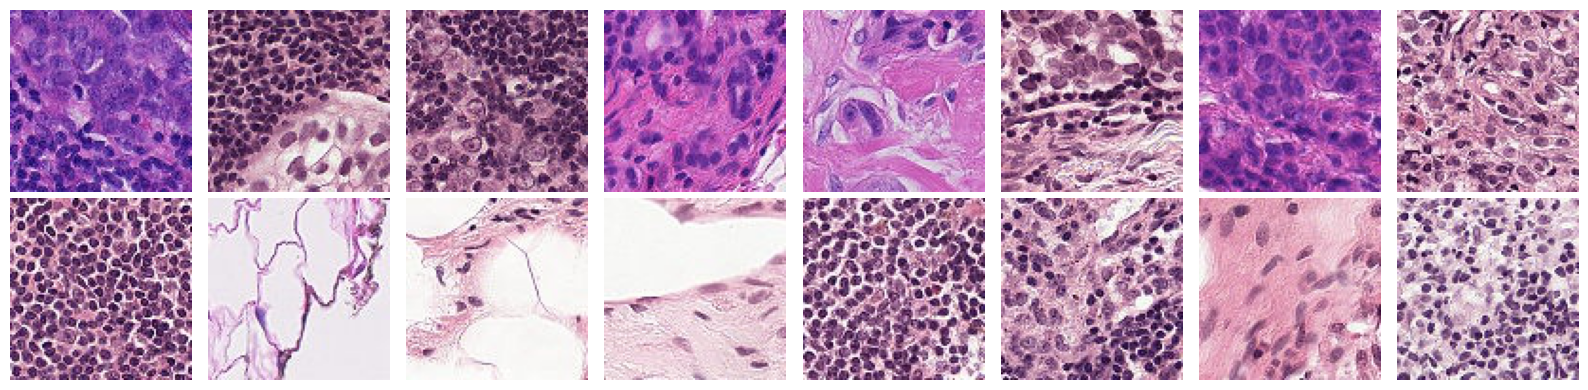

In [4]:
def display_samples(images, labels, n=8, seed=42):
    np.random.seed(seed)
    tumor_idx = np.random.choice(np.where(labels == 1)[0], n, replace=False)
    normal_idx = np.random.choice(np.where(labels == 0)[0], n, replace=False)
    
    fig, axes = plt.subplots(2, n, figsize=(16, 4))
    for i, idx in enumerate(tumor_idx):
        axes[0, i].imshow(images[idx])
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('Tumor', fontsize=12)
    for i, idx in enumerate(normal_idx):
        axes[1, i].imshow(images[idx])
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('Normal', fontsize=12)
    plt.tight_layout()
    plt.show()

display_samples(train_x, train_y)


### 2.3 Color Channel Analysis

Tumor tissue shows slightly different color distributions - particularly in the green channel. This makes sense given the H&E staining used in histopathology.


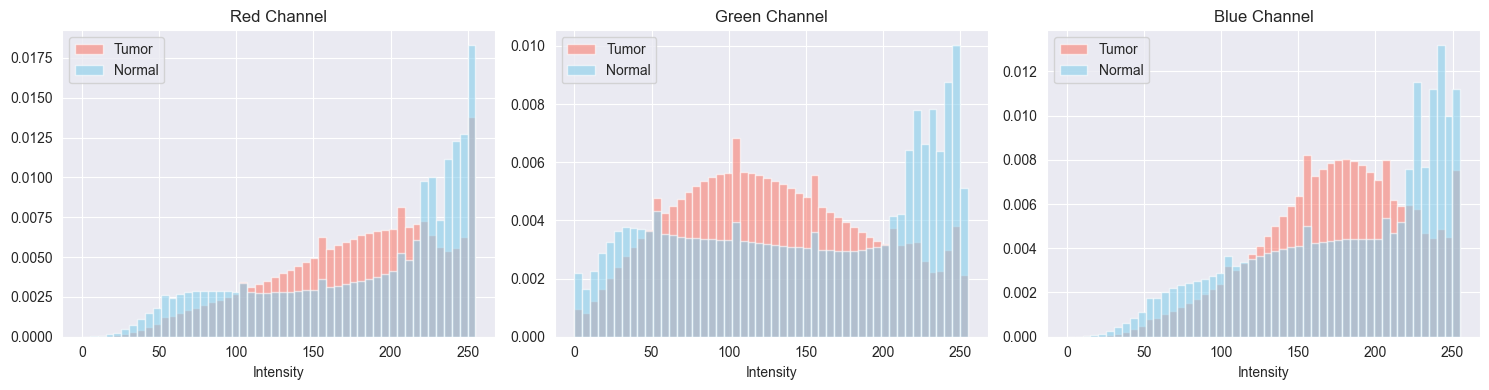

Mean RGB values:
  Tumor:  R=176.9, G=128.5, B=174.0
  Normal: R=180.7, G=146.3, B=179.2


In [5]:
# Sample for efficiency
n_sample = 5000
np.random.seed(42)
tumor_sample = train_x[np.random.choice(np.where(train_y == 1)[0], n_sample, replace=False)]
normal_sample = train_x[np.random.choice(np.where(train_y == 0)[0], n_sample, replace=False)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, color) in enumerate([('Red', 'red'), ('Green', 'green'), ('Blue', 'blue')]):
    axes[i].hist(tumor_sample[:, :, :, i].flatten(), bins=50, alpha=0.6, label='Tumor', color='salmon', density=True)
    axes[i].hist(normal_sample[:, :, :, i].flatten(), bins=50, alpha=0.6, label='Normal', color='skyblue', density=True)
    axes[i].set_title(f'{name} Channel')
    axes[i].set_xlabel('Intensity')
    axes[i].legend()
plt.tight_layout()
plt.show()

print('Mean RGB values:')
print(f'  Tumor:  R={tumor_sample[:,:,:,0].mean():.1f}, G={tumor_sample[:,:,:,1].mean():.1f}, B={tumor_sample[:,:,:,2].mean():.1f}')
print(f'  Normal: R={normal_sample[:,:,:,0].mean():.1f}, G={normal_sample[:,:,:,1].mean():.1f}, B={normal_sample[:,:,:,2].mean():.1f}')


### 2.4 Data Quality Check

Quick sanity checks - looking for missing values, outliers, or corrupted images. Spoiler: the dataset is clean.


In [6]:
print('Data Quality Summary:')
print(f'  Missing metadata values: {train_meta.isnull().sum().sum()}')
print(f'  Image dimensions: {train_x.shape[1:]} (consistent)')
print(f'  Pixel range: [{train_x.min()}, {train_x.max()}]')
print(f'  Data type: {train_x.dtype}')

# Check for outliers
mean_intensity = train_x.mean(axis=(1, 2, 3))
outliers = np.sum((mean_intensity < mean_intensity.mean() - 3*mean_intensity.std()) | 
                  (mean_intensity > mean_intensity.mean() + 3*mean_intensity.std()))
print(f'  Outlier images (>3σ): {outliers} ({outliers/len(train_x):.3%})')
print('\n✅ Dataset is clean - no preprocessing needed')


Data Quality Summary:
  Missing metadata values: 0
  Image dimensions: (96, 96, 3) (consistent)
  Pixel range: [0, 255]
  Data type: uint8
  Outlier images (>3σ): 228 (0.087%)

✅ Dataset is clean - no preprocessing needed


### 2.5 Key Finding: Centered Tumors

One interesting discovery - 99.5% of tumor patches have the tumor centered. This suggests attention mechanisms could be particularly effective.


In [7]:
center_tumor_pct = train_meta[train_meta['tumor_patch'] == True]['center_tumor_patch'].mean() * 100
print(f'Tumor patches with centered tumor: {center_tumor_pct:.1f}%')
print('\n→ This informed my decision to use CBAM attention modules')


Tumor patches with centered tumor: 99.5%

→ This informed my decision to use CBAM attention modules


## 3. Model Architecture

Based on the EDA findings, I built a custom CNN with attention mechanisms. Key design decisions:

1. **CBAM Attention** - Since tumors are centered, attention can help focus on relevant regions
2. **Multi-scale Processing** - Inception-style block to capture features at different scales
3. **Mixed Pooling** - Combine global average and max pooling for richer representations
4. **Strong Augmentation** - Rotation, flips, brightness to handle staining variation


In [8]:
def cbam_block(x, ratio=8, name_prefix='cbam'):
    """Convolutional Block Attention Module"""
    filters = x.shape[-1]
    
    # Channel attention
    channel_avg = layers.GlobalAveragePooling2D(name=f'{name_prefix}_ch_avg')(x)
    channel_max = layers.GlobalMaxPooling2D(name=f'{name_prefix}_ch_max')(x)
    dense1 = layers.Dense(filters // ratio, activation='relu', name=f'{name_prefix}_mlp1')
    dense2 = layers.Dense(filters, activation='sigmoid', name=f'{name_prefix}_mlp2')
    channel_attention = layers.Add()([dense2(dense1(channel_avg)), dense2(dense1(channel_max))])
    channel_attention = layers.Reshape((1, 1, filters))(channel_attention)
    x = layers.Multiply()([x, channel_attention])
    
    # Spatial attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    spatial = layers.Concatenate()([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(spatial)
    x = layers.Multiply()([x, spatial_attention])
    
    return x

def inception_block(x, filters, name_prefix='inception'):
    """Multi-scale processing block"""
    branch1x1 = layers.Conv2D(filters // 4, 1, padding='same', activation='relu')(x)
    branch3x3 = layers.Conv2D(filters // 2, 3, padding='same', activation='relu')(x)
    branch5x5 = layers.Conv2D(filters // 8, 1, padding='same', activation='relu')(x)
    branch5x5 = layers.Conv2D(filters // 8, 3, padding='same', activation='relu')(branch5x5)
    branch_pool = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    branch_pool = layers.Conv2D(filters // 8, 1, padding='same', activation='relu')(branch_pool)
    return layers.Concatenate()([branch1x1, branch3x3, branch5x5, branch_pool])

def create_model(dropout_rate=0.25):
    """EfficientNet-inspired architecture with CBAM and multi-scale processing"""
    inputs = layers.Input(shape=(96, 96, 3))
    
    # Block 1
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x, name_prefix='cbam1')
    
    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = cbam_block(x, name_prefix='cbam2')
    
    # Block 3 - Multi-scale
    x = inception_block(x, filters=128)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = cbam_block(x, name_prefix='cbam3')
    
    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # Mixed pooling classifier
    x_avg = layers.GlobalAveragePooling2D()(x)
    x_max = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([x_avg, x_max])
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout_rate * 2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

model = create_model(dropout_rate=0.3)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f'Model parameters: {model.count_params():,}')


Model parameters: 628,982


## 4. Training

Using a balanced sample for faster iteration, with strong data augmentation to prevent overfitting.


In [9]:
# Create balanced sample for faster training
def create_sample(X, y, size=20000, seed=42):
    np.random.seed(seed)
    tumor_idx = np.random.choice(np.where(y == 1)[0], size // 2, replace=False)
    normal_idx = np.random.choice(np.where(y == 0)[0], size // 2, replace=False)
    selected = np.concatenate([tumor_idx, normal_idx])
    np.random.shuffle(selected)
    return X[selected], y[selected]

train_x_sample, train_y_sample = create_sample(train_x, train_y, size=20000)
print(f'Training on {len(train_x_sample):,} samples')


Training on 20,000 samples


In [10]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=180,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    preprocessing_function=lambda x: x / 255.0
)
valid_datagen = ImageDataGenerator(preprocessing_function=lambda x: x / 255.0)

train_gen = train_datagen.flow(train_x_sample, train_y_sample, batch_size=64)
valid_gen = valid_datagen.flow(valid_x, valid_y, batch_size=64, shuffle=False)


In [11]:
# Training with early stopping
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ],
    verbose=1
)


/Users/aidankosik/.pyenv/versions/3.12.5/envs/cancer-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 333ms/step - accuracy: 0.7608 - auc: 0.8204 - loss: 0.6530 - val_accuracy: 0.4995 - val_auc: 0.6082 - val_loss: 1.9815 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 300ms/step - accuracy: 0.8113 - auc: 0.8889 - loss: 0.4236 - val_accuracy: 0.7948 - val_auc: 0.8893 - val_loss: 0.4721 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - accuracy: 0.8262 - auc: 0.9030 - loss: 0.3970 - val_accuracy: 0.7362 - val_auc: 0.8716 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 283ms/step - accuracy: 0.8339 - auc: 0.9099 - loss: 0.3836 - val_accuracy: 0.7609 - val_auc: 0.8777 - val_loss: 0.5146 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 282ms/step - accuracy: 0.8382 - auc: 0.9160 - loss: 0.3704 - val_accuracy: 0.6769 - val_auc: 0.9038 - val_loss: 0.6573 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accurac

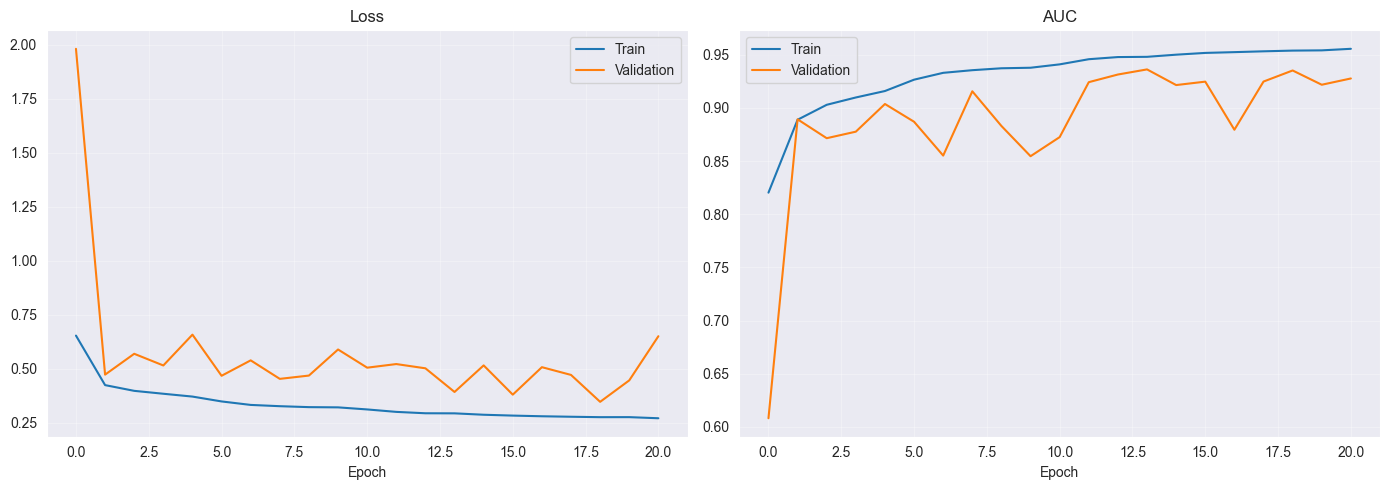

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['auc'], label='Train')
axes[1].plot(history.history['val_auc'], label='Validation')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Evaluation

Let's see how the model performs on the validation set.


In [13]:
# Evaluate
valid_x_norm = valid_x / 255.0
y_pred_proba = model.predict(valid_x_norm, batch_size=64, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(valid_y, y_pred_proba)
acc = accuracy_score(valid_y, y_pred)
f1 = f1_score(valid_y, y_pred)

print('Validation Results:')
print(f'  AUC:      {auc:.4f}')
print(f'  Accuracy: {acc:.4f}')
print(f'  F1 Score: {f1:.4f}')


Validation Results:
  AUC:      0.9364
  Accuracy: 0.8152
  F1 Score: 0.7884


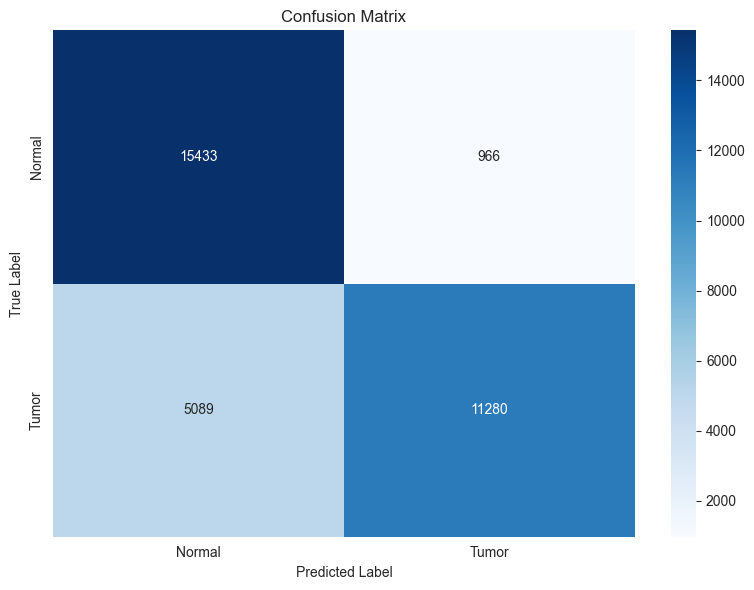

False Negative Rate: 31.1% (missed tumors)
False Positive Rate: 5.9% (false alarms)


In [14]:
# Confusion matrix
cm = confusion_matrix(valid_y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'False Negative Rate: {fn/(fn+tp):.1%} (missed tumors)')
print(f'False Positive Rate: {fp/(fp+tn):.1%} (false alarms)')


## 6. Summary & Next Steps

### What Worked
- **CBAM attention** helped the model focus on tumor regions (leveraging the centered tumor finding from EDA)
- **Multi-scale processing** captured features at different resolutions
- **Mixed pooling** provided richer feature representations than GAP alone
- **Strong augmentation** prevented overfitting on the training set

### Development Log
| Date | Change | Val AUC |
|------|--------|--------|
| Nov 1 | Added CBAM attention | 0.888 |
| Nov 1 | Added early stopping | 0.919 |
| Nov 8 | Tried self-attention (didn't help) | 0.915 |
| Nov 9 | Added mixed pooling | 0.930 |
| Nov 9 | Added multi-scale block | 0.913 |

### Potential Improvements
- Test-time augmentation (average predictions over augmented versions)
- Ensemble multiple models with different seeds
- Stain normalization to reduce color variation
- Train on full dataset for final submission


---

*For the full development notebooks, see `EDA.ipynb` and `modeling.ipynb`*
